# ARTI 403 — Image Processing
## Lab 3 — Image Manipulations using OpenCV

**Student ID:** 2440007196

Input image: `images/input.jpg`. Every result is saved to the `images/` folder.

<class 'numpy.ndarray'> (512, 512, 3) uint8


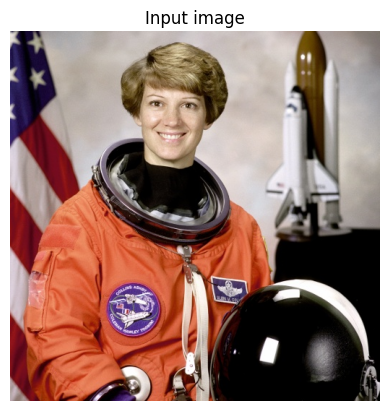

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/input.jpg')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

print(type(img), img.shape, img.dtype)

plt.imshow(rgb)
plt.title('Input image')
plt.axis('off')
plt.show()

## Task 1 — Geometric transformations

### 1. Increase the size of the image (scale by 2)

In [2]:
enlarged = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
cv2.imwrite('images/task1_enlarged.jpg', enlarged)
print('original:', img.shape[:2], ' enlarged:', enlarged.shape[:2])

original: (512, 512)  enlarged: (1024, 1024)


### 2. Rotate the image by 120 degrees

The canvas is enlarged so no corner is cut off.

In [3]:
center = (w / 2, h / 2)
R = cv2.getRotationMatrix2D(center, 120, 1.0)
cos, sin = abs(R[0, 0]), abs(R[0, 1])
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)
R[0, 2] += new_w / 2 - center[0]
R[1, 2] += new_h / 2 - center[1]
rotated = cv2.warpAffine(img, R, (new_w, new_h))
cv2.imwrite('images/task1_rotated_120.jpg', rotated)
print('rotated size:', rotated.shape[:2])

rotated size: (699, 699)


### 3. Shear operations

Horizontal shear moves each row sideways in proportion to its y position; vertical shear does the same for columns.

In [4]:
shx = 0.3
Mx = np.float32([[1, shx, 0],
                 [0, 1,   0]])
sheared_x = cv2.warpAffine(img, Mx, (int(w + shx * h), h))

shy = 0.3
My = np.float32([[1,   0, 0],
                 [shy, 1, 0]])
sheared_y = cv2.warpAffine(img, My, (w, int(h + shy * w)))

cv2.imwrite('images/task1_shear_x.jpg', sheared_x)
cv2.imwrite('images/task1_shear_y.jpg', sheared_y)

True

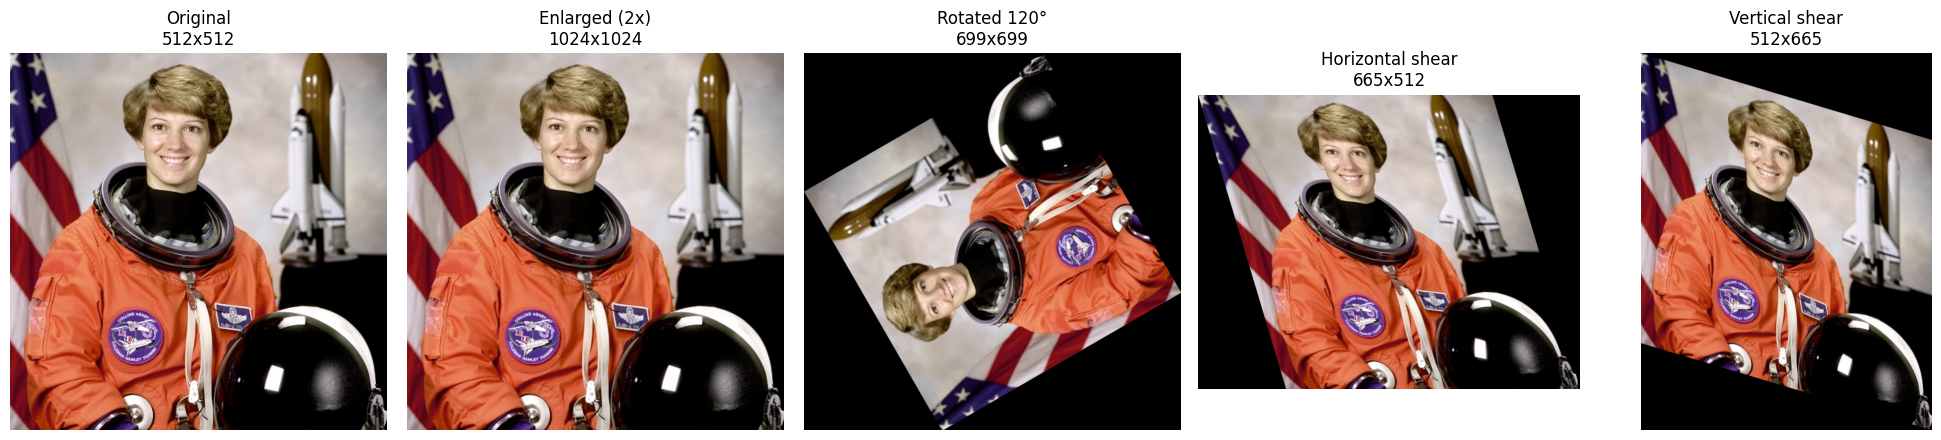

In [5]:
results = [('Original', img), ('Enlarged (2x)', enlarged), ('Rotated 120°', rotated),
           ('Horizontal shear', sheared_x), ('Vertical shear', sheared_y)]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for ax, (title, im) in zip(axes, results):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{title}\n{im.shape[1]}x{im.shape[0]}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('images/task1_results.png', dpi=130)
plt.show()

## Task 2 — Intensity transformations

### 1. Negative image

$s = 255 - r$

In [6]:
negative = 255 - img
cv2.imwrite('images/task2_negative.jpg', negative)

True

### 2. Log transformation

$s = c \log(1 + r)$, with $c = 255 / \log(1 + 255) \approx 45.99$ so the output stays in the range 0–255. The log curve expands dark values, so shadows become brighter.

In [7]:
c = 255 / np.log(1 + 255)
log_img = c * np.log(1 + img.astype(np.float64))
log_img = np.uint8(np.clip(log_img, 0, 255))
cv2.imwrite('images/task2_log.jpg', log_img)
print('c =', round(c, 2))

c = 45.99


### 3. Power-law (gamma) transformation

$s = 255 \, (r / 255)^{\gamma}$. The input is a bright, mid-tone image, so $\gamma = 1.5$ is used: it darkens the mid-tones and stretches the bright end, which increases contrast.

In [8]:
gamma = 1.5
power = 255 * (img.astype(np.float64) / 255) ** gamma
power = np.uint8(np.clip(power, 0, 255))
cv2.imwrite('images/task2_power_gamma1.5.jpg', power)

True

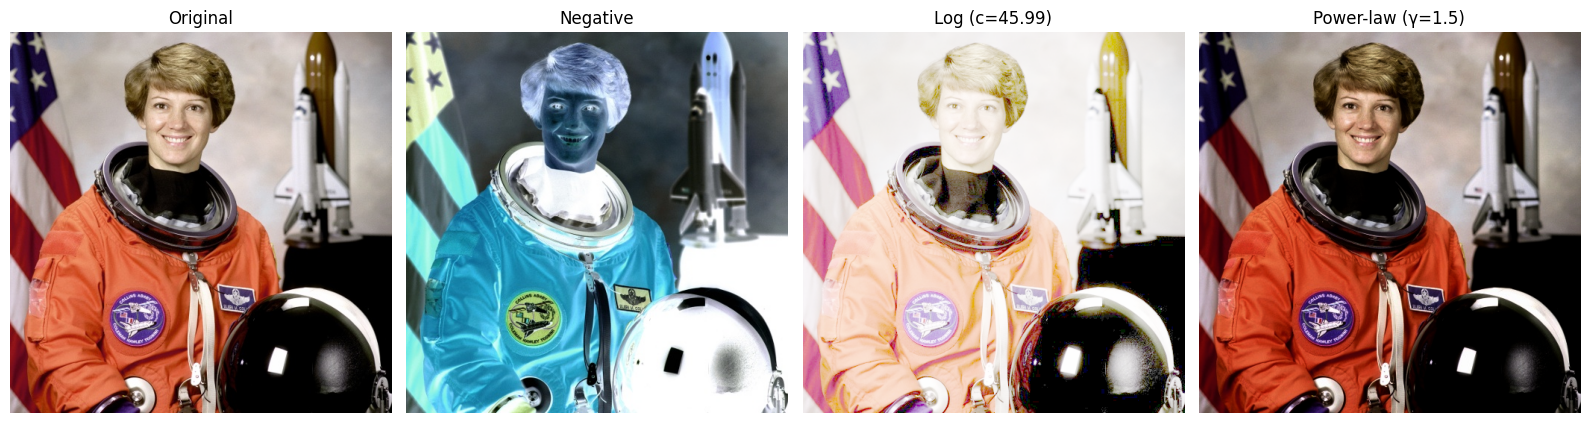

In [9]:
results = [('Original', img), ('Negative', negative),
           (f'Log (c={c:.2f})', log_img), (f'Power-law (γ={gamma})', power)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (title, im) in zip(axes, results):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('images/task2_results.png', dpi=130)
plt.show()

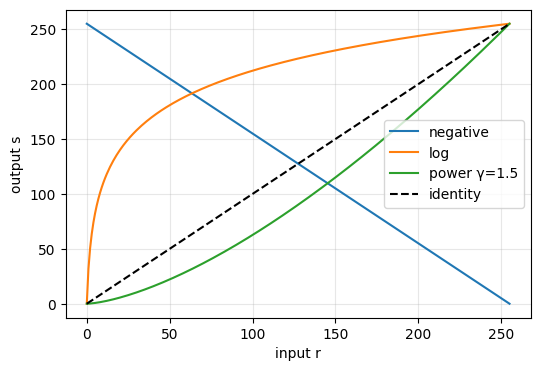

In [10]:
r = np.arange(256)
plt.figure(figsize=(6, 4))
plt.plot(r, 255 - r, label='negative')
plt.plot(r, c * np.log(1 + r), label='log')
plt.plot(r, 255 * (r / 255) ** gamma, label=f'power γ={gamma}')
plt.plot(r, r, 'k--', label='identity')
plt.xlabel('input r')
plt.ylabel('output s')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('images/task2_curves.png', dpi=130)
plt.show()